# BTC Forecast Project

# 1. Import Libraries

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.4 MB/s eta 0:00:00


In [ ]:
import kagglehub

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

from IPython.display import display

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.api import qqplot
from statsmodels.tsa.arima.model import ARIMA

import pmdarima as pm

from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb


# 2. Load Dataset

In [ ]:
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'comprehensive-btcusd-1m-data' dataset.
Path to dataset files: /kaggle/input/comprehensive-btcusd-1m-data


In [ ]:
df = pd.read_csv("/kaggle/input/comprehensive-btcusd-1m-data/BTCUSD_1m_Binance.csv")
df.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,2017-08-17 04:00:59.999,7564.906851,3.0,0.075183,320.390851,0.0
1,2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000,2017-08-17 04:01:59.999,0.000000,0.0,0.000000,0.000000,0.0
2,2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074,2017-08-17 04:02:59.999,1117.542921,2.0,0.261074,1117.542921,0.0
3,2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008,2017-08-17 04:03:59.999,51.171852,3.0,0.012008,51.171852,0.0
4,2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796,2017-08-17 04:04:59.999,599.999338,1.0,0.140796,599.999338,0.0


#3. Data Overview

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (4278671, 12)

Columns: ['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time', 'Quote asset volume', 'Number of trades', 'Taker buy base asset volume', 'Taker buy quote asset volume', 'Ignore']


In [ ]:
print(df.dtypes)

Open time                        object
Open                            float64
High                            float64
Low                             float64
Close                           float64
Volume                          float64
Close time                       object
Quote asset volume              float64
Number of trades                float64
Taker buy base asset volume     float64
Taker buy quote asset volume    float64
Ignore                          float64
dtype: object


In [ ]:
print(df.isnull().sum())

Open time                       0
Open                            0
High                            0
Low                             0
Close                           0
Volume                          0
Close time                      0
Quote asset volume              0
Number of trades                0
Taker buy base asset volume     0
Taker buy quote asset volume    0
Ignore                          0
dtype: int64


# 4. Date Column Handling

## 4.1. Datetime Conversion

In [ ]:
df['Open time'] = pd.to_datetime(df['Open time'])

print(f"Date Column Type: {df['Open time'].dtype}")
print(f"Earliest Date: {df['Open time'].min()}")
print(f"Latest Date {df['Open time'].max()}")

Date Column Type: datetime64[ns]
Earliest Date: 2017-08-17 04:00:00
Latest Date 2025-10-11 11:02:00


In [ ]:
print(type(df.index))

<class 'pandas.core.indexes.range.RangeIndex'>


In [ ]:
df.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,2017-08-17 04:00:59.999,7564.906851,3.0,0.075183,320.390851,0.0
1,2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000,2017-08-17 04:01:59.999,0.000000,0.0,0.000000,0.000000,0.0
2,2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074,2017-08-17 04:02:59.999,1117.542921,2.0,0.261074,1117.542921,0.0
3,2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008,2017-08-17 04:03:59.999,51.171852,3.0,0.012008,51.171852,0.0
4,2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796,2017-08-17 04:04:59.999,599.999338,1.0,0.140796,599.999338,0.0


## 4.2. Resampling

In [ ]:
df = df.set_index('Open time')

df_daily = df['Close'].resample('D').last()

df_daily = df_daily.dropna()
df_daily = df_daily.reset_index()             # bring the date back as a regular column

df_daily.columns = ['ds', 'y']                # rename to Prophet's required column names

print("Daily shape:", df_daily.shape)
print("\n=== First 5 rows ===")
display(df_daily.head())
print("\n=== Last 5 rows ===")
display(df_daily.tail())

Daily shape: (2978, 2)

=== First 5 rows ===


,ds,y
0,2017-08-17,4285.08
1,2017-08-18,4108.37
2,2017-08-19,4139.98
3,2017-08-20,4086.29
4,2017-08-21,4016.00



=== Last 5 rows ===


,ds,y
2973,2025-10-07,121332.95
2974,2025-10-08,123306.00
2975,2025-10-09,121662.40
2976,2025-10-10,112774.50
2977,2025-10-11,112072.32


In [ ]:
print(f"Date range: {df_daily['ds'].min()} -> {df_daily['ds'].max()}")
print(f"Total days: {len(df_daily)}")
print(f"Any nulls? {df_daily.isnull().sum().sum()}")
print(f"Is sorted? {df_daily['ds'].is_monotonic_increasing}")
print(f"\nPrice range: {df_daily['y'].min():,.2f} -> {df_daily['y'].max():,.2f}")

Date range: 2017-08-17 00:00:00 -> 2025-10-11 00:00:00
Total days: 2978
Any nulls? 0
Is sorted? True

Price range: 3,189.02 -> 124,658.54


# 5. Data Split

In [ ]:
HORIZON = 365

print(f"Test set ratio: {HORIZON / len(df_daily) *100:.2f}")

Test set ratio: 12.26


In [ ]:
df_train = df_daily.iloc[:-HORIZON].copy().reset_index(drop=True)
df_test  = df_daily.iloc[-HORIZON:].copy().reset_index(drop=True)

print(f"Total rows  : {len(df_daily)}")
print(f"Train rows  : {len(df_train)} ({df_train['ds'].min().date()} : {df_train['ds'].max().date()})")
print(f"Test rows   : {len(df_test)}  ({df_test['ds'].min().date()} : {df_test['ds'].max().date()})")

Total rows  : 2978
Train rows  : 2613 (2017-08-17 : 2024-10-11)
Test rows   : 365  (2024-10-12 : 2025-10-11)


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_train['ds'], y=df_train['y'],
    mode='lines', name='Train',
    line={'color': 'blue'}
))

fig.add_trace(go.Scatter(
    x=df_test['ds'], y=df_test['y'],
    mode='lines', name='Test',
    line={'color': 'orange'}
))

fig.add_vline(
    x=df_test['ds'].iloc[0].date(),
    line_dash='dash',
    line_color='white',
)

fig.update_layout(
    title='BTC Price — Train / Test Split',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    yaxis={'tickprefix': '$', 'tickformat': ',.0f'},
    hovermode='x unified',
    template='plotly_dark',
    height=550
)

fig.show()

# 5. EDA

## 5.1. Decomposition

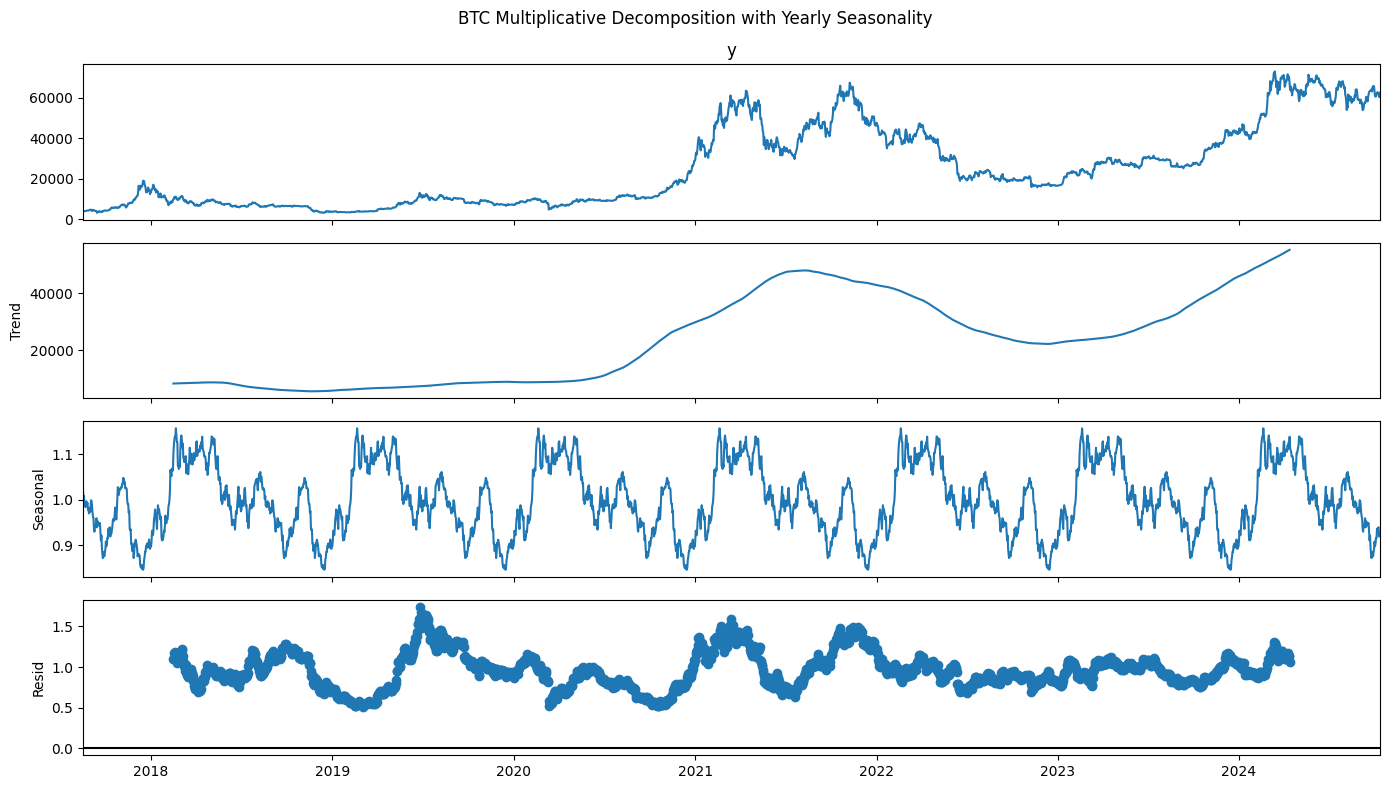

In [ ]:
plt.rcParams['figure.figsize'] = (14, 8)

# We use multiplicative model because the variance grows with price level
decompose = seasonal_decompose(df_train.set_index('ds')['y'],
                               model='multiplicative',
                               period=365)    # yearly seasonality

decompose.plot()
plt.suptitle('BTC Multiplicative Decomposition with Yearly Seasonality')
plt.tight_layout()
plt.show()

* Strong upward trend with shifts $\rightarrow$ Requires Prophet's changepoint detection
* Weak yearly seasonality (±15%) $\rightarrow$ Enable yearly_seasonality=True in Prophet
* Large structured residuals $\rightarrow$ Prohet and ARIMA not perfectly fit (expected high MAE/RMSE)

## 5.2. Stationarity test (ADF test)

In [ ]:
result = adfuller(df_train['y'], autolag='AIC')

print('======= ADF Test =======')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Lags used     : {result[2]}')
print(f'\nCritical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

if result[1] > 0.05:
    print('\nConclusion: Series is NON-STATIONARY (p > 0.05) -> ARIMA needs d=1')
else:
    print('\nConclusion: Series is STATIONARY (p < 0.05)')

======= ADF Test =======
ADF Statistic : -1.1942
p-value       : 0.6761
Lags used     : 28

Critical Values:
   1%: -3.4329
   5%: -2.8627
   10%: -2.5674

Conclusion: Series is NON-STATIONARY (p > 0.05) -> ARIMA needs d=1


## 5.3. ACF and PACF Analysis

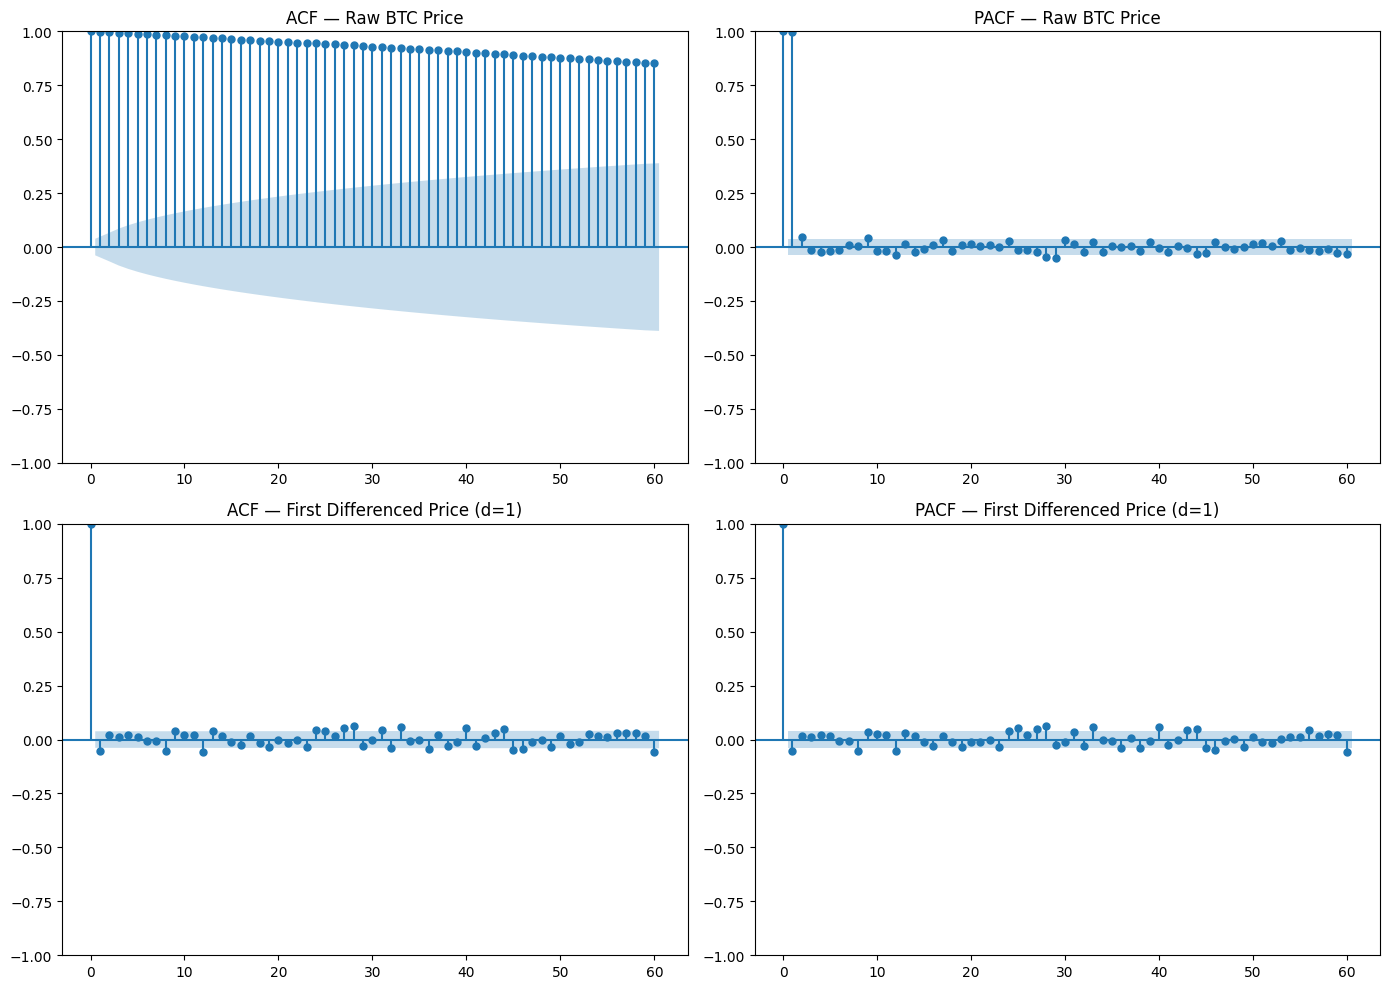

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# ACF
plot_acf(df_train['y'], lags=60, ax=axs[0, 0])
axs[0, 0].set_title('ACF — Raw BTC Price')

# PACF
plot_pacf(df_train['y'], lags=60, ax=axs[0, 1])
axs[0, 1].set_title('PACF — Raw BTC Price')

# Differencing (d=1)
df_train['y_diff'] = df_train['y'].diff().dropna()

plot_acf(df_train['y_diff'].dropna(), lags=60, ax=axs[1, 0])
axs[1, 0].set_title('ACF — First Differenced Price (d=1)')

plot_pacf(df_train['y_diff'].dropna(), lags=60, ax=axs[1, 1])
axs[1, 1].set_title('PACF — First Differenced Price (d=1)')

plt.tight_layout()
plt.show()

* Non-stationary $\rightarrow$ ARIMA must use (d=1)
* ACF decays slowly and PACF cuts off at lag 1 $\rightarrow$ confirms (d=1)
* After differencing, both ACF/PACF is $\approx$ 0 $\rightarrow$ d=1 is sufficient, d=2 is not needed

# 8. Modelling

## 8.1. Prophet

### 8.1.1. Prophet Fitting

In [ ]:
prophet_model = Prophet(
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

prophet_model.fit(df_train)
print("Prophet fitted successfully")

Prophet fitted successfully


### 8.1.2. Prophet Forecast

In [ ]:
prophet_forecast = prophet_model.predict(df_test[['ds']])

In [ ]:
print("Forecast shape:", prophet_forecast.shape)

Forecast shape: (365, 19)


In [ ]:
display(prophet_forecast.head())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-10-12,71853.601764,59082.700403,78100.403682,71853.601764,71853.601764,-3155.492615,-3155.492615,-3155.492615,-9.311828,-9.311828,-9.311828,-3146.180787,-3146.180787,-3146.180787,0.0,0.0,0.0,68698.109148
1,2024-10-13,71945.711127,60181.370831,78357.788776,71945.711127,71945.711127,-2942.532533,-2942.532533,-2942.532533,-7.209628,-7.209628,-7.209628,-2935.322904,-2935.322904,-2935.322904,0.0,0.0,0.0,69003.178594
2,2024-10-14,72037.820490,59215.670260,78909.681332,72037.820490,72037.820490,-2652.669278,-2652.669278,-2652.669278,65.978593,65.978593,65.978593,-2718.647870,-2718.647870,-2718.647870,0.0,0.0,0.0,69385.151212
3,2024-10-15,72129.929854,60126.264182,79389.478101,72129.929854,72129.929854,-2511.648209,-2511.648209,-2511.648209,-13.514143,-13.514143,-13.514143,-2498.134066,-2498.134066,-2498.134066,0.0,0.0,0.0,69618.281645
4,2024-10-16,72222.039217,60597.818930,79638.228549,72222.039217,72223.147059,-2237.362481,-2237.362481,-2237.362481,38.507714,38.507714,38.507714,-2275.870194,-2275.870194,-2275.870194,0.0,0.0,0.0,69984.676736


In [ ]:
display(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

,ds,yhat,yhat_lower,yhat_upper
0,2024-10-12,68698.109148,59082.700403,78100.403682
1,2024-10-13,69003.178594,60181.370831,78357.788776
2,2024-10-14,69385.151212,59215.670260,78909.681332
3,2024-10-15,69618.281645,60126.264182,79389.478101
4,2024-10-16,69984.676736,60597.818930,79638.228549


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_train.tail(365)['ds'],
    y=df_train.tail(365)['y'],
    mode='lines',
    name='Training Data (Last 365 days)',
    line={'color': 'blue'}
))

fig.add_trace(go.Scatter(
    x=df_test['ds'],
    y=df_test['y'],
    mode='lines',
    name='Test Data (Actual)',
    line={'color': 'orange'}
))

fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'],
    y=prophet_forecast['yhat'],
    mode='lines',
    name='Prophet Forecast',
    line={'color': 'green', 'dash': 'dash'}
))

fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'].tolist() + prophet_forecast['ds'].tolist()[::-1],
    y=prophet_forecast['yhat_upper'].tolist() + prophet_forecast['yhat_lower'].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(0, 128, 0, 0.2)',
    line={'color': 'rgba(255,255,255,0)'},
    hoverinfo="skip",
    showlegend=True,
    name='Confidence Interval'
))

fig.update_layout(
    title='Bitcoin Price: Actual vs. Prophet Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    yaxis={'tickprefix': '$', 'tickformat': ',.0f'},
    hovermode='x unified',
    template='plotly_dark'
)

fig.show()

### 8.1.3. Prophet Evaluation

In [ ]:
y_true = df_test['y'].values
y_pred = prophet_forecast['yhat'].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("=== Prophet Backtest Metrics ===")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")

=== Prophet Backtest Metrics ===
MAE  : $13,627.87
RMSE : $15,226.76


### 8.1.4. Prophet Insights

* Ther is a gap between the Prophet forecast and the actual test data.
* Prophet predicted a steady continuation of the 2023 trend. Instead, the actual price had a massive rise at the end of 2025 from 70k\$ to 100k\$.
* The true price broke out of the upper boundary.
* The model was usually under-predicting the actual price.

## 8.2. ARIMA

### 8.2.1. Data Preparation for ARIMA

In [ ]:
# Set timestamp as index
arima_train = df_train.set_index('ds')['y']
arima_test = df_test.set_index('ds')['y']

print(f"===== Training Set =====")
display(arima_train.head())
print(f"\n===== Test Set =====")
display(df_test.head())

===== Training Set =====


,y
ds,
2017-08-17,4285.08
2017-08-18,4108.37
2017-08-19,4139.98
2017-08-20,4086.29
2017-08-21,4016.00



===== Test Set =====


,ds,y
0,2024-10-12,63206.22
1,2024-10-13,62870.02
2,2024-10-14,66083.99
3,2024-10-15,67074.14
4,2024-10-16,67620.01


In [ ]:
# Resampling and forward-fill (ffill)
arima_train = arima_train.asfreq('D').ffill()
arima_test = arima_test.asfreq('D').ffill()

print(f"Training data frequency: {arima_train.index.freqstr}")
print(f"Testing data frequency:  {arima_test.index.freqstr}")

Training data frequency: D
Testing data frequency:  D


In [ ]:
missing_before = df_train['y'].isna().sum()
missing_after = arima_train.isna().sum()
print(f"Missing values before ffil: {missing_before}")
print(f"Missing values after ffil: {missing_after}")

Missing values before ffil: 0
Missing values after ffil: 0


### 8.2.2. ARIMA (0, 1, 0)

In [ ]:
arima_model = ARIMA(arima_train, order=(0, 1, 0))

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2613
Model:                 ARIMA(0, 1, 0)   Log Likelihood              -21893.303
Date:                Thu, 23 Apr 2026   AIC                          43788.605
Time:                        14:19:11   BIC                          43794.473
Sample:                    08-17-2017   HQIC                         43790.731
                         - 10-11-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.116e+06   1.37e+04     81.505      0.000    1.09e+06    1.14e+06
Ljung-Box (L1) (Q):                   6.91   Jarque-Bera (JB):              7261.19
Prob(Q):                              0.01   Pr

### 8.2.3. ARIMA(0, 1, 0) Evaluation

In [ ]:
print("=== ARIMA(0, 1, 0) Backtest Metrics ===")

forecast_steps = len(arima_test)
arima_forecast = arima_result.forecast(steps=forecast_steps)

y_true_arima = arima_test.values
y_pred_arima = arima_forecast.values

arima_mae = mean_absolute_error(y_true_arima, y_pred_arima)
arima_rmse = np.sqrt(mean_squared_error(y_true_arima, y_pred_arima))

print(f"ARIMA MAE  : ${arima_mae:,.2f}")
print(f"ARIMA RMSE : ${arima_rmse:,.2f}")

=== ARIMA(0, 1, 0) Backtest Metrics ===
ARIMA MAE  : $36,742.36
ARIMA RMSE : $39,345.18


### 8.2.4. ARIMA(0, 1, 0) Visualization

In [ ]:
arima_ci = arima_result.get_forecast(steps=forecast_steps).conf_int(alpha=0.05)
lower_bound = arima_ci.iloc[:, 0]
upper_bound = arima_ci.iloc[:, 1]

fig_arima = go.Figure()

fig_arima.add_trace(go.Scatter(
    x=arima_train.index[-365:],
    y=arima_train.values[-365:],
    mode='lines',
    name='Training Data (Past)',
    line={'color': 'blue'}
))

fig_arima.add_trace(go.Scatter(
    x=arima_test.index,
    y=arima_test.values,
    mode='lines',
    name='Test Data (Actual)',
    line={'color': 'orange'}
))

fig_arima.add_trace(go.Scatter(
    x=arima_test.index,
    y=y_pred_arima,
    mode='lines',
    name='ARIMA(0,1,0) Forecast',
    line={'color': 'red', 'dash': 'dash'}
))

fig_arima.add_trace(go.Scatter(
    x=arima_test.index.tolist() + arima_test.index.tolist()[::-1],
    y=upper_bound.tolist() + lower_bound.tolist()[::-1],
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line={'color': 'rgba(255,255,255,0)'},
    hoverinfo="skip",
    showlegend=True,
    name='95% Confidence Interval'
))

fig_arima.update_layout(
    title='Bitcoin Price: Actual vs. ARIMA(0,1,0) Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    hovermode='x unified',
    template='plotly_dark'
)

fig_arima.show()

### 8.2.5. AutoArima

In [ ]:
auto_model = pm.auto_arima(
    arima_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=1,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n=== Best Model Summary ===")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=43789.441, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=43784.493, Time=0.33 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=43784.774, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=43788.605, Time=0.14 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=43785.586, Time=0.53 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=43785.872, Time=0.85 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=43787.287, Time=2.00 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=43783.783, Time=0.22 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=43784.828, Time=0.29 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=43785.089, Time=0.29 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=43784.061, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=43785.592, Time=0.25 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 5.850 seconds

=== Best Model Summary ===
                               SARIMAX Results  

### 8.2.6. AutoArima (1, 1, 0) Evaluation

In [ ]:
auto_forecast = auto_model.predict(n_periods=forecast_steps)

y_true_auto = arima_test.values
y_pred_auto = auto_forecast.values

auto_mae = mean_absolute_error(y_true_auto, y_pred_auto)
auto_rmse = np.sqrt(mean_squared_error(y_true_auto, y_pred_auto))

print(f"Auto-ARIMA MAE  : ${auto_mae:,.2f}")
print(f"Auto-ARIMA RMSE : ${auto_rmse:,.2f}")

Auto-ARIMA MAE  : $36,849.92
Auto-ARIMA RMSE : $39,445.63


### 8.2.7. AutoArima (1, 1, 0) Visualization

In [ ]:
auto_forecast_values, auto_ci = auto_model.predict(n_periods=forecast_steps, return_conf_int=True, alpha=0.05)

lower_bound_auto = auto_ci[:, 0]
upper_bound_auto = auto_ci[:, 1]

fig_auto = go.Figure()

fig_auto.add_trace(go.Scatter(
    x=arima_train.index[-365:],
    y=arima_train.values[-365:],
    mode='lines',
    name='Training Data (Past)',
    line={'color': 'blue'}
))

fig_auto.add_trace(go.Scatter(
    x=arima_test.index,
    y=arima_test.values,
    mode='lines',
    name='Test Data (Actual)',
    line={'color': 'orange'}
))

fig_auto.add_trace(go.Scatter(
    x=arima_test.index,
    y=y_pred_auto,
    mode='lines',
    name='Auto-ARIMA(1,1,0) Forecast',
    line={'color': 'red', 'dash': 'dash'}
))

fig_auto.add_trace(go.Scatter(
    x=arima_test.index.tolist() + arima_test.index.tolist()[::-1],
    y=upper_bound_auto.tolist() + lower_bound_auto.tolist()[::-1],
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line={'color': 'rgba(255,255,255,0)'},
    hoverinfo="skip",
    showlegend=True,
    name='95% Confidence Interval'
))

fig_auto.update_layout(
    title='Bitcoin Price: Actual vs. Auto-ARIMA(1,1,0) Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    hovermode='x unified',
    template='plotly_dark'
)

fig_auto.show()

*  Both Arima (0, 1, 0) and AutoArima (1, 1, 0) have a very poor performance

## 8.3. SARIMA

### 8.3.1. Auto-SARIMA

In [ ]:
sarima_model = pm.auto_arima(
    arima_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=1,
    seasonal=True,
    m=7,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=0,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n=== Best SARIMA Model Summary ===")
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=43789.441, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=43786.254, Time=0.60 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=43786.555, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=43788.605, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=43784.493, Time=0.13 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=43786.262, Time=0.65 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=43775.860, Time=3.49 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=43776.819, Time=7.87 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=43789.706, Time=1.55 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=43787.567, Time=1.25 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=43787.454, Time=1.48 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=43778.605, Time=9.45 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=43781.762, Time=2.60 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=43776.972, Time=4.70 sec
 ARIMA(1,1,1)(1,0,1

### 8.3.2. SARIMA (2,1,1)(1,0,1)[7] Evaluation

In [ ]:
sarima_forecast_values, sarima_ci = sarima_model.predict(n_periods=365, return_conf_int=True, alpha=0.05)

lower_bound_sarima = sarima_ci[:, 0]
upper_bound_sarima = sarima_ci[:, 1]

y_true_sarima = arima_test.values

sarima_mae = mean_absolute_error(y_true_sarima, sarima_forecast_values)
sarima_rmse = np.sqrt(mean_squared_error(y_true_sarima, sarima_forecast_values))

print(f"SARIMA MAE  : ${sarima_mae:,.2f}")
print(f"SARIMA RMSE : ${sarima_rmse:,.2f}")

SARIMA MAE  : $35,994.11
SARIMA RMSE : $38,485.85


### 8.3.3. SARIMA Visualization

In [ ]:
fig_sarima = go.Figure()

fig_sarima.add_trace(go.Scatter(
    x=arima_train.index[-365:],
    y=arima_train.values[-365:],
    mode='lines',
    name='Training Data (Past)',
    line={'color': 'blue'}
))

fig_sarima.add_trace(go.Scatter(
    x=arima_test.index,
    y=arima_test.values,
    mode='lines',
    name='Test Data (Actual)',
    line={'color': 'orange'}
))

fig_sarima.add_trace(go.Scatter(
    x=arima_test.index,
    y=sarima_forecast_values,
    mode='lines',
    name='SARIMA Forecast',
    line={'color': 'red', 'dash': 'dash'}
))

fig_sarima.add_trace(go.Scatter(
    x=arima_test.index.tolist() + arima_test.index.tolist()[::-1],
    y=upper_bound_sarima.tolist() + lower_bound_sarima.tolist()[::-1],
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line={'color': 'rgba(255,255,255,0)'},
    hoverinfo="skip",
    showlegend=True,
    name='95% Confidence Interval'
))

fig_sarima.update_layout(
    title='Bitcoin Price: Actual vs. SARIMA Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    hovermode='x unified',
    template='plotly_dark'
)

fig_sarima.show()

## 8.4. XGBoost

> Instead of predicting the absolute price, we will predict the daily difference (which the ADF test proved is stationary). This prevents the tree-BASED modelS from failing at extrapolation

### 8.4.1. Feature Engineering (Lags)

In [ ]:
# Differencing to keep it stationary
xgb_data = pd.DataFrame({'y_diff': arima_train.diff()})

# Lag features (1 to 7 days)
for i in range(1, 8):
    xgb_data[f'lag_{i}'] = xgb_data['y_diff'].shift(i)

# Rolling window
xgb_data['rolling_mean_7'] = xgb_data['y_diff'].shift(1).rolling(window=7).mean()
xgb_data['rolling_mean_30'] = xgb_data['y_diff'].shift(1).rolling(window=30).mean()
xgb_data['rolling_std_7'] = xgb_data['y_diff'].shift(1).rolling(window=7).std()

# Drop NaNs (The first 7 days will contain NaNs)
xgb_data = xgb_data.dropna()

print("Shape of engineered dataset:", xgb_data.shape)
display(xgb_data.head())



Shape of engineered dataset: (2582, 11)


,y_diff,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7,rolling_mean_30,rolling_std_7
ds,,,,,,,,,,,
2017-09-17,-14.96,14.95,510.98,-755.67,-219.03,-44.75,78.10,-128.44,-77.694286,-19.004333,379.183233
2017-09-18,335.02,-14.96,14.95,510.98,-755.67,-219.03,-44.75,78.10,-61.482857,-13.612667,379.077902
2017-09-19,-124.97,335.02,-14.96,14.95,510.98,-755.67,-219.03,-44.75,-24.780000,-3.499000,406.304848
2017-09-20,-10.04,-124.97,335.02,-14.96,14.95,510.98,-755.67,-219.03,-36.240000,-5.875000,408.089388
2017-09-21,-290.01,-10.04,-124.97,335.02,-14.96,14.95,510.98,-755.67,-6.384286,-3.866667,400.053414


### 8.4.2. Data Split for XGB

In [ ]:
HORIZON = 365

print(f"Test set ratio: {HORIZON / len(xgb_data) *100:.2f}")

Test set ratio: 14.14


In [ ]:
X = xgb_data.drop(columns=['y_diff'])
y = xgb_data['y_diff']

X_train_xgb = X.iloc[:-HORIZON]
y_train_xgb = y.iloc[:-HORIZON]

X_test_xgb = X.iloc[-HORIZON:]
y_test_xgb = y.iloc[-HORIZON:]

print(f"X_train_xgb shape: {X_train_xgb.shape}, y_train_xgb shape: {y_train_xgb.shape}")
print(f"X_test_xgb shape:  {X_test_xgb.shape}, y_test_xgb shape:  {y_test_xgb.shape}")
print(f"Train end date: {X_train_xgb.index.max().date()}")
print(f"Test start date: {X_test_xgb.index.min().date()}")
print(f"Test end date: {X_test_xgb.index.max().date()}")

X_train_xgb shape: (2217, 10), y_train_xgb shape: (2217,)
X_test_xgb shape:  (365, 10), y_test_xgb shape:  (365,)
Train end date: 2023-10-12
Test start date: 2023-10-13
Test end date: 2024-10-11


### 8.4.3. XGB Fitting

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### 8.4.4. XGB Evaluation

In [ ]:
y_pred_diff = xgb_model.predict(X_test_xgb)

# Reconstructing the absolute prices (inverse transformation)
master_prices = df_daily.set_index('ds')['y']
yesterday_prices = master_prices.shift(1).loc[X_test_xgb.index]
xgb_pred_abs = yesterday_prices + y_pred_diff
y_true_abs = master_prices.loc[X_test_xgb.index]

xgb_mae = mean_absolute_error(y_true_abs, xgb_pred_abs)
xgb_rmse = np.sqrt(mean_squared_error(y_true_abs, xgb_pred_abs))

print(f"XGBoost MAE  : ${xgb_mae:,.2f}")
print(f"XGBoost RMSE : ${xgb_rmse:,.2f}")

XGBoost MAE  : $1,201.72
XGBoost RMSE : $1,656.22


### 8.4.5. XGB Visualization

In [ ]:
fig_xgb = go.Figure()

train_subset = master_prices.loc[:X_test_xgb.index[0]].tail(365)
fig_xgb.add_trace(go.Scatter(
    x=train_subset.index,
    y=train_subset.values,
    mode='lines',
    name='Training Data (Past)',
    line={'color': 'blue'}
))

fig_xgb.add_trace(go.Scatter(
    x=y_true_abs.index,
    y=y_true_abs.values,
    mode='lines',
    name='Test Data (Actual)',
    line={'color': 'orange'}
))

fig_xgb.add_trace(go.Scatter(
    x=xgb_pred_abs.index,
    y=xgb_pred_abs.values,
    mode='lines',
    name='XGBoost Prediction',
    line={'color': 'green', 'dash': 'dash'}
))

fig_xgb.update_layout(
    title='Bitcoin Price: Actual vs. XGBoost Prediction',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    hovermode='x unified',
    template='plotly_dark'
)

fig_xgb.show()

* The model is making a naive forecast that the price of today is almost the price of yesterday.
* That is why the MAE and RMSE are so small.
* However, this model is not reliable.

In [ ]:
xgb_model.feature_importances_

array([0.07741152, 0.09380552, 0.08964736, 0.10653152, 0.09201828,
       0.10148437, 0.10895848, 0.09792097, 0.10748261, 0.12473932],
      dtype=float32)

input validation:
* .csv
* time column
  * Close -> let the user validate and select
  * datetime type
  * set index or not
* price column
  * comma

* NaNs
* Resampling
* NaNs after resampling